In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import TwoSlopeNorm
from pathlib import Path
import pandas as pd
from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import FuncFormatter

In [2]:
from dask.distributed import LocalCluster, Client
# 
cluster = LocalCluster(
    n_workers=8,              
    threads_per_worker=4,     
    memory_limit="16GB"        
)

client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 119.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35767,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38125,Total threads: 4
Dashboard: http://127.0.0.1:42137/status,Memory: 14.90 GiB
Nanny: tcp://127.0.0.1:44895,


In [10]:
def rfilter(da):
    weight = xr.DataArray([0.1, 0.25, 0.5, 0.25, 0.1], dims=["y"])

    return da.rolling(plev = 5, center = True, min_periods = 3).construct(plev = "y").dot(weight)
    
def plot_panel(ax, da, title, levels):
    time_vals = da["time"].values
    pressure = da["pressure"].values
    data = da.values

    im = da.plot.contourf(
        ax=ax,
        x="time",
        y="pressure",
        levels=levels,
        cmap="BrBG",
        add_colorbar=False,
        extend="both",
    )

    cl_1 = ax.contour(time_vals, pressure, data.T, levels=[0.5], colors="black")
    cl_2 = ax.contour(time_vals, pressure, data.T, levels=[1.0], colors="black")
    
    ax.clabel(cl_1, fmt="%g", fontsize=22)
    ax.clabel(cl_2, fmt="%g", fontsize=22)

    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.set_ylim(100, 0.1)
    ax.set_yticks([0.1, 1, 10, 30, 100])
    ax.yaxis.set_major_formatter(ScalarFormatter())

    ax.set_ylabel("Pressure [hPa]", fontsize=22)
    ax.set_title(title, fontsize=22)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=45, labelsize=22)
    ax.tick_params(axis="y", labelsize=22)
    ax.yaxis.set_major_formatter(FuncFormatter(pressure_formatter))
    return im

def pressure_formatter(x, pos):
    if x >= 1:
        return f"{int(x)}"   # no .0 for >= 1
    else:
        return f"{x:.1f}"    # keep decimal for < 1

def process_socol(ds):
    ds = ds.sortby("plev", ascending = False)
    ds["h2o_ppmv"] = ds["H2O_m"] * 1e6
    ds["plev"] = ds["plev"] / 100
    ds["plev"].attrs["units"] = "hPa"
    ds["time"] = pd.date_range("2021-01-01", freq="1ME", periods=ds.time.shape[0])
    return ds

def cal_gm(ds, var, swoosh = True):
    
    
    if swoosh == True:
        weights_ds = np.cos(np.deg2rad(ds.lat))
        weights_ds.name = "weights"
        ds_gm = ds.sel(time = slice("2022", "2025-11")).weighted(weights_ds).mean(["lat"]).load()
    else:
        weights_ds = np.cos(np.deg2rad(ds[var].lat))
        weights_ds.name = "weights"
        ds_gm = ds[var].sel(time = slice("2022", "2025-11")).weighted(weights_ds).mean(["lat","lon"]).load()
    return ds_gm

def process_swoosh(ds):
    ds["h2o_ppmv"] = ds["combinedanomh2oq"]
    ds = ds["h2o_ppmv"]
    ds["time"] = pd.date_range("1984-01-16", freq="1ME", periods=ds.time.shape[0])
    ds = ds.rename({"level": "plev"}).sel(time = slice("2022", "2025-11"))
    return ds

In [4]:
infile_path = Path("/sto0/data/Intermediate/Hunga_Tonga_byAles/ht/")
what = "chem_mm_zon"
infiles_w = list(infile_path.glob(f"socol4_htt1?_{what}*")) # with HT forcing
infiles_wo = list(infile_path.glob(f"socol4_htt2?_{what}*")) # without

socol_wo = xr.open_mfdataset(
    infiles_wo[:],
    parallel=False,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
).pipe(process_socol)

socol_w = xr.open_mfdataset(
    infiles_w[:],
    parallel=False,  #  will be performed in parallel using dask.delayed
    combine="nested",
    concat_dim=["ens"],
).pipe(process_socol)

/tmp/ipykernel_1822434/453962768.py:6: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  socol_wo = xr.open_mfdataset(


In [5]:
inpath = "/sto4/data/Intermediate/swoosh/swoosh_h2oanom_198401-2026-01.nc"  
swoosh_anom = xr.open_dataset(inpath).pipe(process_swoosh).pipe(rfilter)

In [6]:
swoosh_anom_gm = cal_gm(swoosh_anom, "h2o_ppmv", swoosh = True)
socol_anom_gm = cal_gm(socol_w, "h2o_ppmv", swoosh = False).mean("ens").sel(time = slice("2022", "2025-11")) - cal_gm(socol_wo, "h2o_ppmv", swoosh = False).mean("ens").sel(time = slice("2022", "2025-11"))

In [7]:
path = "/sto0/data/Intermediate/Hunga_Tonga_byAles/MLSv6_H2O_202201-2025-11_smoothed.nc"
mls_da = xr.open_dataset(path)
mls_da = mls_da.h2o.sel(time = slice("2022", "2025-11"))

/tmp/ipykernel_1822434/2987878824.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


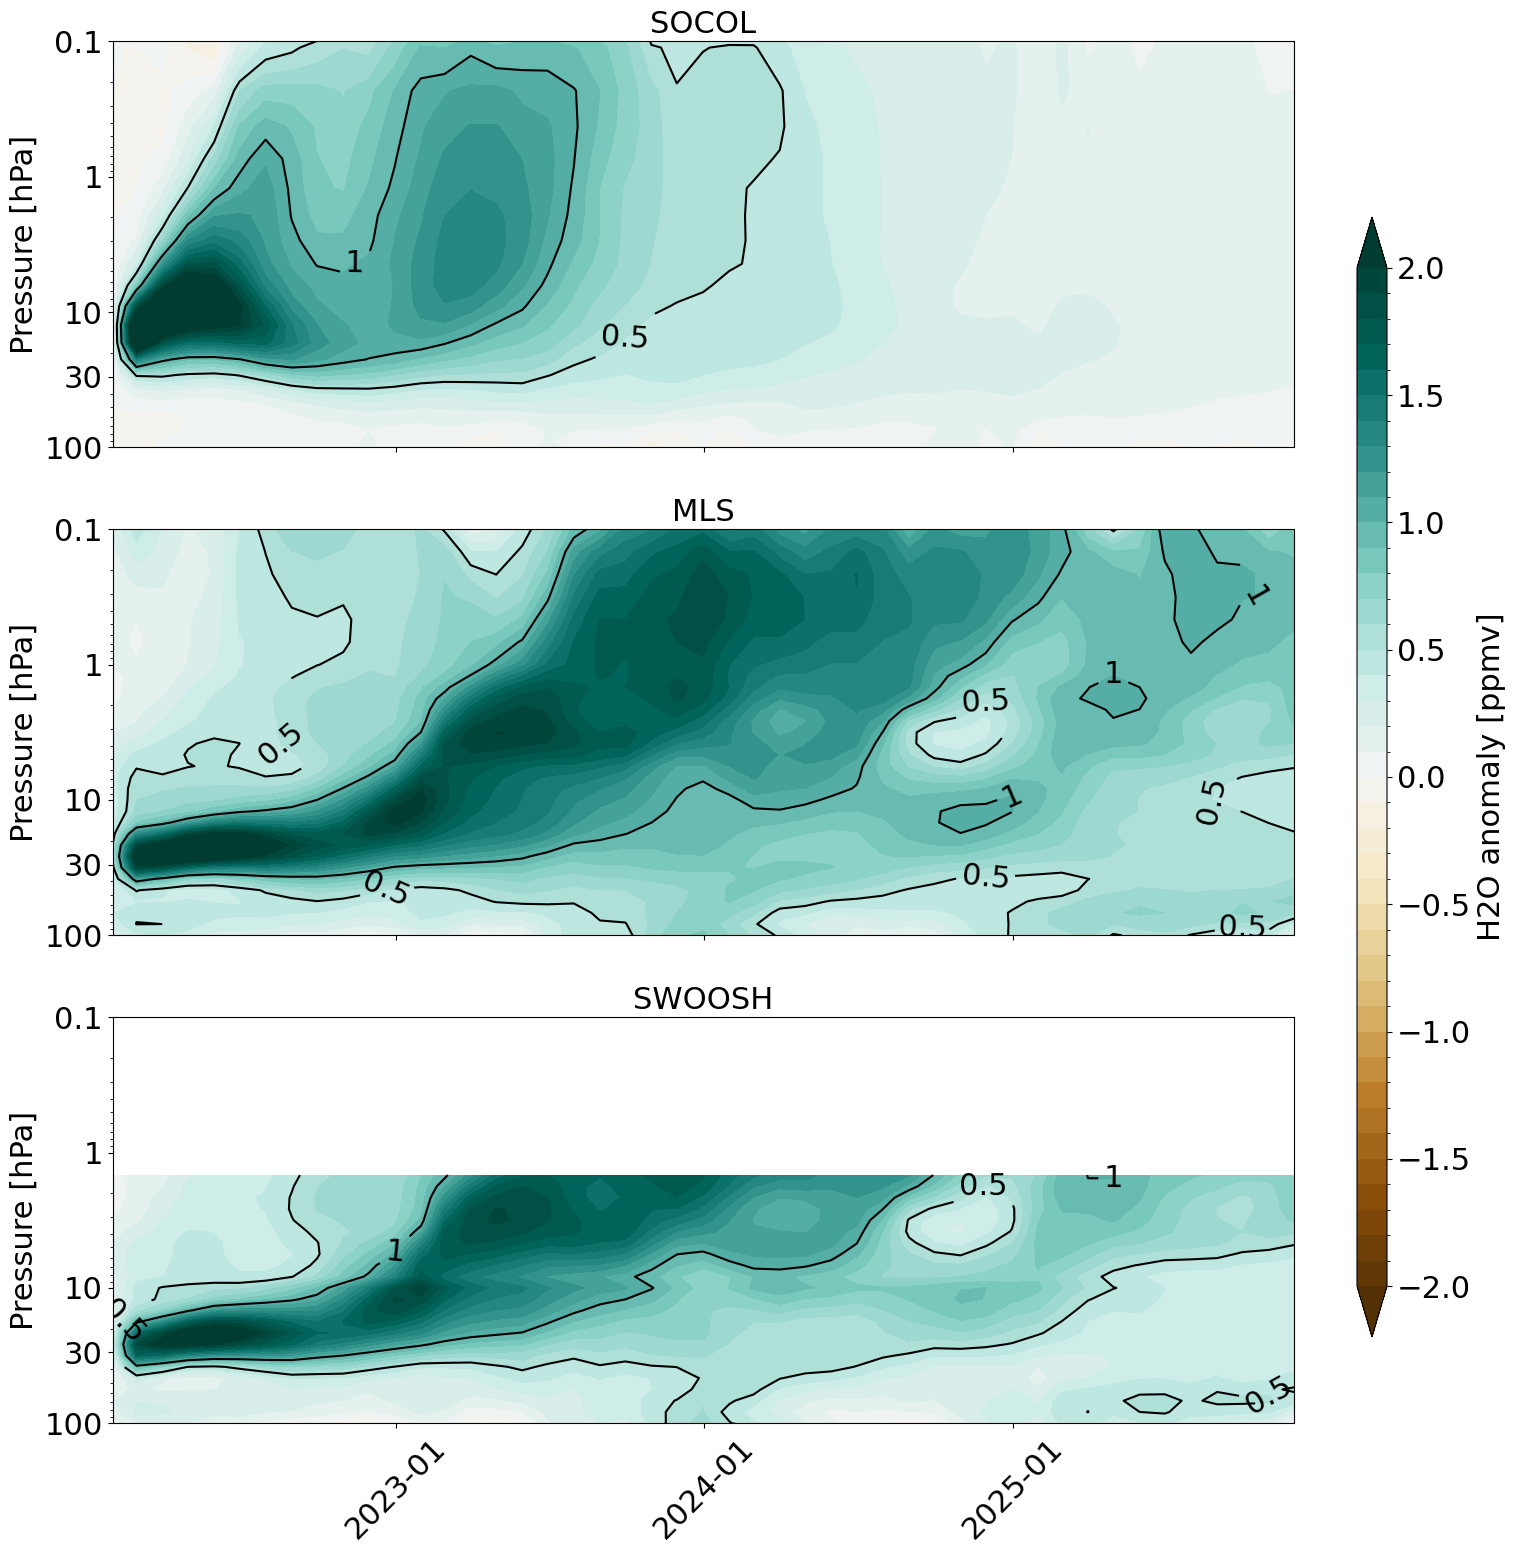

In [13]:
# Prepare MLS
mls_da = xr.DataArray(
    mls_da.values,
    dims=["time", "pressure"],
    coords={"time": mls_da["time"].values, 
            "pressure": mls_da["pressure"].values,
    },
    attrs={"units": "ppmv"},
    name="H2O anomaly",
)

# Prepare SWOOSH
swoosh_da = xr.DataArray(
    swoosh_anom_gm.values,
    dims=["time", "pressure"],
    coords={
        "time": swoosh_anom_gm["time"].values,
        "pressure": swoosh_anom_gm["plev"].values,
    },
    attrs={"units": "ppmv"},
    name="H2O anomaly",
)

# Prepare SOCOL
socol_da = xr.DataArray(
    socol_anom_gm.values,
    dims=["time", "pressure"],
    coords={
        "time": socol_anom_gm["time"].values,
        "pressure": socol_anom_gm["plev"].values,
    },
    attrs={"units": "ppmv"},
    name="H2O anomaly",
)


# Create figure

levels = np.linspace(-2, 2, 41)
plt.rcParams.update({"font.size": 22})
fig, axes = plt.subplots(3, 1, figsize=(15, 16), sharex=True)

im = plot_panel(axes[0], socol_da, "SOCOL", levels)
plot_panel(axes[1], mls_da, "MLS", levels)
plot_panel(axes[2], swoosh_da, "SWOOSH", levels)

# bottom x-label
axes[0].set_xlabel("")
axes[1].set_xlabel("")
axes[2].set_xlabel("", fontsize=0)

# Create colorbar

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 

cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("H2O anomaly [ppmv]", fontsize=22)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig("Fig_A1_h2o_anom_socol_MLS_SWOOSH.pdf", bbox_inches="tight")
plt.show()

# Optional save
